In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "pyresdmd").exists():
            return path
    raise RuntimeError("Could not find repo root containing pyproject.toml and pyresdmd/")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Found pyresdmd root.")

Found pyresdmd root.


In [2]:
import numpy as np
import time
import torch
import matplotlib.pyplot as plt

from pyresdmd.compute.spectra import (
    compute_eigendecomposition_from_weights,
    compute_pseudospectra,
)
from pyresdmd.dicts.fourier_mode_dictionary import FourierModeDictionary
from pyresdmd.dicts.hermite_dictionary import HermiteDictionary
from pyresdmd.dicts import TensorProductDictionary
from pyresdmd.dicts.nn.relu.relu_dictionary import ReLUDictionary
from pyresdmd.dicts.trainable_dictionary import TrainableDictionary
from pyresdmd.utils.helpers import benchmark_metrics
from pyresdmd.utils.plotters import plot_curve, plot_pseudospec
from pyresdmd.sims.pendulum import pendulum_cts

print("Imports successful.")

Imports successful.


In [3]:
if torch.cuda.is_available():
    print("CUDA is available. Using GPU for computations.")
    device = torch.device("cuda")
else:
    print("No CUDA-supported device found. Using CPU for computations.")
    device = torch.device("cpu")

CUDA is available. Using GPU for computations.


In [4]:
# change this cell to change simulation parameters
noise : float = 0.0
n_trajectories : int = 140
steps : int = 126
epochs : int = 1000
patience : int = 50
dictionary_size : int = 60

dt : float = 0.2
g : float = 9.81

print("Simulation parameters set.")

Simulation parameters set.


In [ ]:
def rand_point() -> torch.Tensor:
    '''Generates a random point in the state space, sampled uniformly from [-pi, pi] x [-1, 1].'''
    x = 2*torch.pi*torch.rand(1) - torch.pi
    y = 2*torch.rand(1) - 1
    return torch.stack((x, y)).squeeze()

initial_states = [rand_point() for _ in range(n_trajectories)]
x, y = pendulum_cts(initial_states, dt = dt, g = g, steps = steps, noise = noise, device = device)

print("Trajectory data generated.")

Trajectory data generated.


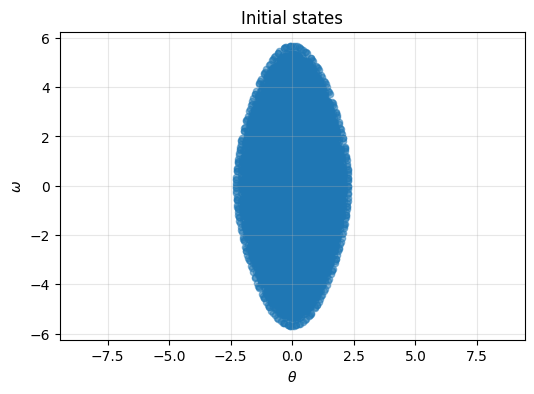

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(x.cpu().detach().numpy()[:,0], x.cpu().detach().numpy()[:,1], alpha=0.5, s=20)
plt.xlabel('$\\theta$')
plt.ylabel('$\\omega$')
plt.title('Initial states')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Initial eigenvalues: tensor([ 0.9977+0.0000j,  1.0000+0.0000j,  0.9574+0.0000j,  0.8173+0.5587j,
         0.8173-0.5587j,  0.8669+0.4725j,  0.8669-0.4725j,  0.5270+0.8147j,
         0.5270-0.8147j,  0.3571+0.8777j,  0.3571-0.8777j,  0.0710+0.9544j,
         0.0710-0.9544j,  0.7162+0.4737j,  0.7162-0.4737j, -0.1845+0.8647j,
        -0.1845-0.8647j, -0.3911+0.8032j, -0.3911-0.8032j, -0.7383+0.4656j,
        -0.7383-0.4656j, -0.4624+0.5965j, -0.4624-0.5965j, -0.7334+0.0723j,
        -0.7334-0.0723j, -0.6632+0.2675j, -0.6632-0.2675j, -0.6671+0.0000j,
         0.1769+0.6072j,  0.1769-0.6072j,  0.3545+0.4361j,  0.3545-0.4361j,
         0.3047+0.3267j,  0.3047-0.3267j,  0.3736+0.1314j,  0.3736-0.1314j,
         0.4505+0.0000j,  0.4084+0.0000j, -0.2388+0.4693j, -0.2388-0.4693j,
        -0.4535+0.2204j, -0.4535-0.2204j, -0.0973+0.4450j, -0.0973-0.4450j,
        -0.0384+0.4306j, -0.0384-0.4306j, -0.3118+0.3241j, -0.3118-0.3241j,
         0.1275+0.3480j,  0.1275-0.3480j, -0.3590+0.0000j, -0.2661+

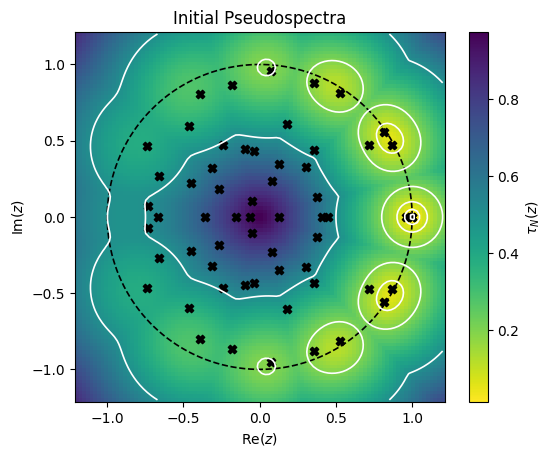

In [7]:
# generates trainable dictionary and computes initial metrics.
base = ReLUDictionary(input_dim = 2, n_functions = dictionary_size)
dictionary = TrainableDictionary(base)
dictionary.to(device)

with torch.no_grad():
    report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
init_eigvals = report['eigenvalues']
init_loss = report['loss']
init_cond_num = report['cond_num']
init_forecast_error = report['forecast_error']
init_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
del Psi_X, Psi_Y
eps_levels = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]

print(f"Initial eigenvalues: {init_eigvals}")
print(f"Initial loss: {init_loss}")
print(f"Initial condition number: {init_cond_num}")
print(f"Initial forecast error: {init_forecast_error}")

re_vals = init_pseudospec['re_vals']
im_vals = init_pseudospec['im_vals']
tau_grid = init_pseudospec['tau_grid']

plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = init_eigvals, displayname = 'Initial Pseudospectra', save = False)

Fourier x Hermite eigvals: tensor([ 0.9263+0.0000j,  0.2500+0.7817j,  0.2500-0.7817j, -0.2596+0.8001j,
        -0.2596-0.8001j,  0.6659+0.5029j,  0.6659-0.5029j,  0.6750+0.4479j,
         0.6750-0.4479j,  0.7792+0.0000j, -0.5628+0.4837j, -0.5628-0.4837j,
         0.3504+0.4831j,  0.3504-0.4831j, -0.6261+0.1356j, -0.6261-0.1356j,
        -0.5491+0.0000j, -0.5746+0.0000j, -0.4984+0.0000j, -0.1649+0.4082j,
        -0.1649-0.4082j,  0.1339+0.4407j,  0.1339-0.4407j, -0.0779+0.3261j,
        -0.0779-0.3261j,  0.1311+0.3474j,  0.1311-0.3474j,  0.2039+0.2305j,
         0.2039-0.2305j, -0.1851+0.0000j, -0.1571+0.0000j,  0.0936+0.1019j,
         0.0936-0.1019j,  0.1292+0.0000j, -0.0290+0.1002j, -0.0290-0.1002j],
       device='cuda:0')
Fourier x Hermite loss: 0.6617606282234192
Fourier x Hermite condition number: 10.799254417419434
Fourier x Hermite forecast error: 0.531358540058136


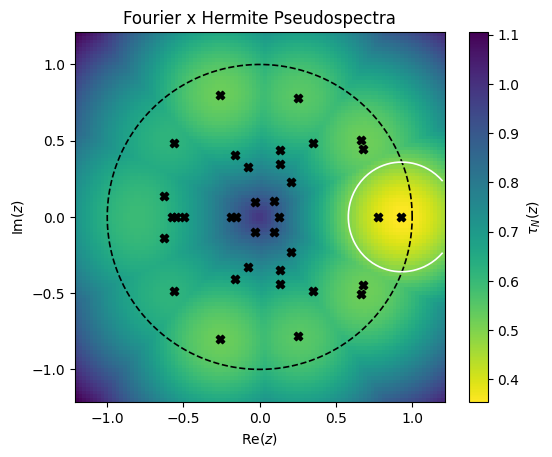

In [8]:
# generates Fourier x Hermite benchmark dictionary and gives statistics
base_root = int(dictionary_size**0.5)
total_ratio = 5 + 3
f_size = max(1, int(round(base_root * 5/total_ratio)))
h_size = max(1, int(round(base_root * 3/total_ratio)))
if f_size * h_size == 0:
    f_size = max(1, base_root)
    h_size = max(1, base_root)

fh_dict = TensorProductDictionary(FourierModeDictionary(f_size), HermiteDictionary(h_size))
fh_dict.to(device)
fh_metrics = benchmark_metrics(fh_dict, x, y)
Lambda = fh_metrics['Lambda']
fh_cond_num = fh_metrics['cond_num']
fh_loss = fh_metrics['loss']
fh_forecast_error = fh_metrics['forecast_error']
fh_pseudospec = fh_metrics['pseudospec']

print(f"Fourier x Hermite eigvals: {Lambda}")
print(f"Fourier x Hermite loss: {fh_loss}")
print(f"Fourier x Hermite condition number: {fh_cond_num}")
print(f"Fourier x Hermite forecast error: {fh_forecast_error}")

re_vals = fh_pseudospec['re_vals']
im_vals = fh_pseudospec['im_vals']
tau_grid = fh_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = Lambda, displayname = 'Fourier x Hermite Pseudospectra', save = False)

Best loss: 0.044104285538196564
Condition number of best model: 408.8106384277344
Forecast error of best model: 0.00027302015223540366


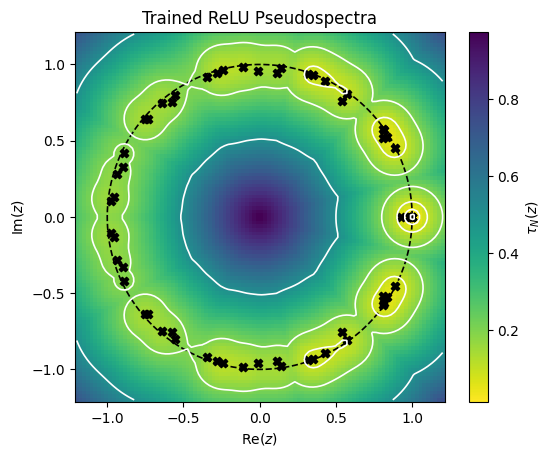

In [9]:
trained = dictionary.fit(x, y, epochs = epochs, patience = patience)
train_losses = trained['train_losses']
test_losses = trained['test_losses']
train_cond_nums = trained['train_cond_nums']
test_cond_nums = trained['test_cond_nums']
train_forecast_errors = trained['train_forecast_errors']
test_forecast_errors = trained['test_forecast_errors']
final_epoch = trained['final_epoch']

with torch.no_grad():
    best_report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
best_loss = best_report['loss']
best_cond_num = best_report['cond_num']
best_forecast_error = best_report['forecast_error']
final_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
W = torch.ones(x.shape[0], device = x.device) / x.shape[0]
final_eigvals, _ = compute_eigendecomposition_from_weights(Psi_X, Psi_Y, W)

print(f"Best loss: {best_loss}")
print(f"Condition number of best model: {best_cond_num}")
print(f"Forecast error of best model: {best_forecast_error}")
re_vals = final_pseudospec['re_vals']
im_vals = final_pseudospec['im_vals']
tau_grid = final_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = final_eigvals, displayname = 'Trained ReLU Pseudospectra', save = False)

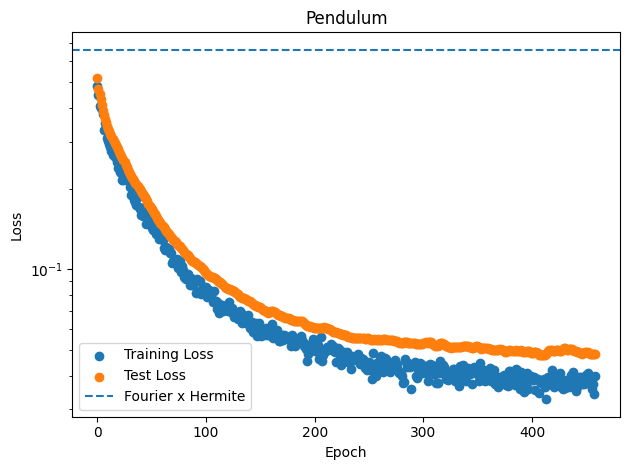

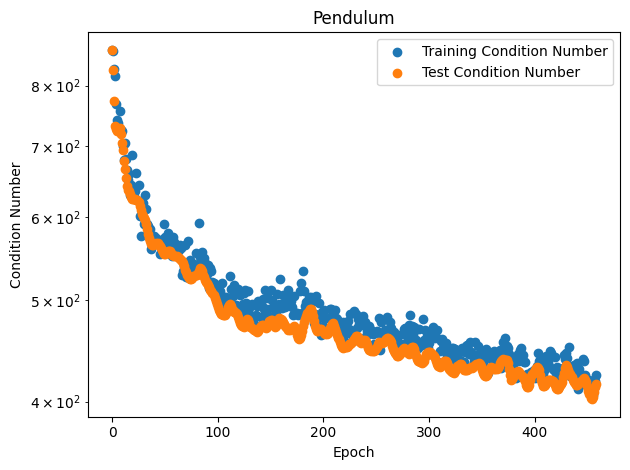

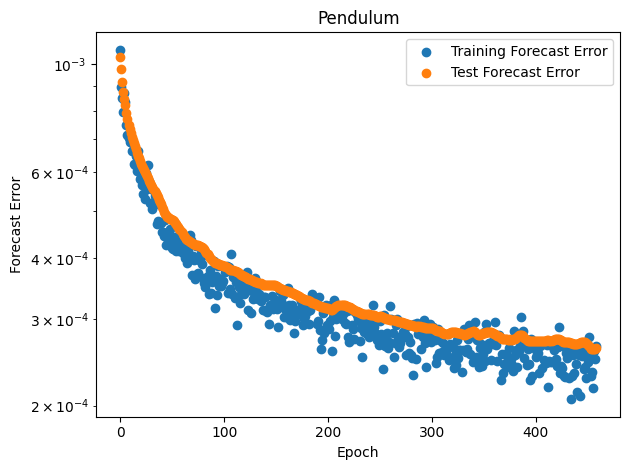

In [10]:
show_fh_cond_num = False
show_fh_loss = True
show_fh_forecast_error = False

add_values_loss = {'Fourier x Hermite': fh_loss} if show_fh_loss else {}
add_values_cond_num = {'Fourier x Hermite': fh_cond_num} if show_fh_cond_num else {}
add_values_forecast_error = {'Fourier x Hermite': fh_forecast_error} if show_fh_forecast_error else {}

plot_curve(final_epoch, train_losses, test_losses, add_values = add_values_loss, 
                   displayname = 'Pendulum', ylabel = 'Loss', save_plot = False)

plot_curve(final_epoch, train_cond_nums, test_cond_nums, add_values = add_values_cond_num,
                        displayname = 'Pendulum', ylabel = 'Condition Number', save_plot = False)

plot_curve(final_epoch, train_forecast_errors, test_forecast_errors, add_values = add_values_forecast_error,
                        displayname = 'Pendulum', ylabel = 'Forecast Error', save_plot = False)

In [11]:
# cleanup VRAM
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()